### Zernike Holography

Optical aberration often prevents high quality imaging and projection.
Aberration can be modeled as a phase distortion upon an optical wavefront:
while a flat wavefront is free of aberration, non-ideal optical elements impart
a sort of distortion hologram on the beam leading to distorted spots.
Zernike polynomials act as a good (i.e., orthonormal under some conditions) basis to describe
optical aberration, with terms corresponding directly to common forms of aberration.

A SLM can therefore apply these Zernike polynomials to either distort a corrected wavefront or correct a distorted wavefront.
For example, defocus $Z_4 = Z_2^0$ translates a spot in $z$ in the same way
that the tilts $Z_2 = Z_1^1$ and $Z_1 = Z_1^{-1}$ translate it in $x$ and $y$,
while the higher orders reshape the projected spots themselves.
So instead of mapping power to points in 2D space, we can map power
to points in **Zernike aberration space**, where every spot in a hologram carries its own Zernike
vector.

This example builds that idea up from the bottom by showing how to:

-   Properly index, efficiently compute (`ZernikeBasis`), and apply Zernikes to a desired region on the SLM (`slm.aperture`)
-   Create 3D holograms by simply adding a defocus term to the usual two tilts,
-   Produce "aberration-space" holograms in which each spot is given a different set of high order terms, and
-   Interpolate a Zernike vector across the field of view, which is the machinery behind the
    full-field aberration correction demonstrated in the following tutorial.



#### Initialization

To start, we initialize our system:

In [1]:
# Header. This is hidden from sphinx with the json metadata:
#   {"nbsphinx":"hidden"}

# ipython configuration (reloads source code automatically and plots inline)
%load_ext autoreload
%autoreload 2
%matplotlib inline

import os, sys
import numpy as np

import matplotlib as mpl
import matplotlib.pyplot as plt

mpl.rc('image', cmap='inferno')

[INF] 21:27:43 PLM Initialized PLM on display 2.
[INF] 21:27:47 FLIR Cam Initialized FLIR.
[WRN] 21:27:48 FLIR Cam Attempted to set WOI to (2148, 1024, 1004, 1024), but realized (2148, 1024, 1000, 1024).
[INF] 21:27:48 FLIR Cam-PLM Initialized FourierSLM.
[INF] 21:27:48 FLIR Cam-PLM Loaded 'pixel' calibration from 'slm2_pixel_calibration_1-5V.h5'.
[INF] 21:27:48 FLIR Cam-PLM Loaded 'wavefront' calibration from 'slm2_superpixel_calibration_offset=0-25_wav=488.h5'.
[WRN] 21:27:48 FLIR Cam-PLM remove_background is enabled and a noise floor was detected; removing this background (4.2% of the average normalization).


smooth: 100%|██████████| 16/16 [00:00<00:00, 32.11it/s]


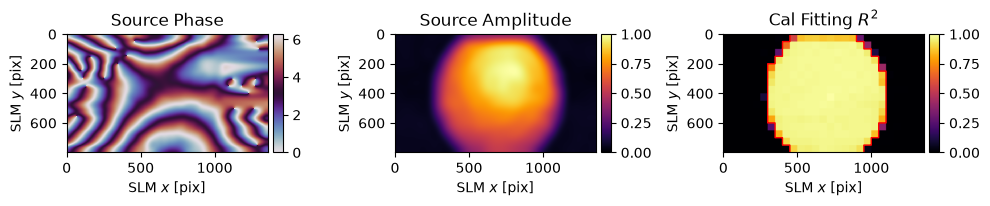

In [2]:
# Try to load physical hardware.
from slmsuite.hardware.cameraslms import FourierSLM

try:
    from slmsuite.hardware.slms.texasinstruments import PLM
    from slmsuite.hardware.cameras.flir import FLIR

    # Load the hardware.
    slm = PLM(
        'p67',
        display_number=2,
        configure_usb=True,
        usb_device_number=1,
        wav_um=0.488,
        settle_time_s=0.05,
        name='PLM',
    )

    cam = FLIR(
        serial="22562470",
        pitch_um=2.74,
        bitdepth=12,
        name="FLIR Cam"
    )

    # For this camera, we also want to crop the WOI to the center 1024x1024 area.
    cam.set_woi((1024, 1024))       # (w, h) centers the WOI on the sensor.

    # Load the composite CameraSLM.
    fs = FourierSLM(cam, slm)

    # Load pixel calibration (also called LUT or gamma correction).
    fs.load_calibration('pixel', 'slm2_pixel_calibration_1-5V.h5')
    fs.pixel_calibration_process(plot=False)

    # Load wavefront calibration.
    fs.load_calibration('wavefront', 'slm2_superpixel_calibration_offset=0-25_wav=488.h5')
    fs.wavefront_calibration_superpixel_process(r2_threshold=.5, smooth=True, plot=True)

    # We'll also add a blazed grating to the SLM source to roughly center the reflection on our camera.
    # This won't be necessary for most setups, but is used here to some peculiarities of our dual-SLM setup.
    from slmsuite.holography import toolbox
    slm.source['phase'] += toolbox.phase.blaze(slm, toolbox.convert_vector((0.28,-0.01), from_units="freq", to_units="norm", hardware=fs))
    slm.set_phase(None)

# Fallback to virtual hardware.
except Exception as e:
    print(f"Loading physical hardware failed; loading virtual hardware. Error:\n{str(e)}")
    from slmsuite.hardware.slms.simulated import SimulatedSLM
    from slmsuite.hardware.cameras.simulated import SimulatedCamera

    # Make the SLM and camera.
    slm = SimulatedSLM((1600, 1200), pitch_um=(8,8))
    # Program the simulated and calibrated sources to be flat phase.
    slm.set_source_analytic(sim=True)
    slm.set_source_analytic()

    cam = SimulatedCamera(slm, (1440, 1100), pitch_um=(4,4), gain=200)

    # Tie the camera and SLM together with an analytic calibration.
    fs = FourierSLM(cam, slm)
    M, b = fs.fourier_calibration_build(
        f_eff=80000.,                              # f_eff of 80000 wavelengths or 80 mm with the default 1 um wavelength
        theta=5 * np.pi / 180,
    )
    cam.set_affine(M, b)
    fs.fourier_calibrate_analytic(M, b)

# Fit the SLM's aperture to its source. This is the subject of the next section.
slm.fit_aperture();

[INF] 21:27:50 Fourier Grid Initialized SpotHologram.


Fourier Grid: 100%|██████████| 10/10 [00:00<00:00, 181.93it/s]


[INF] 21:27:50 FLIR Cam Autoexpose: 2.11e-02 s - 1987/4095


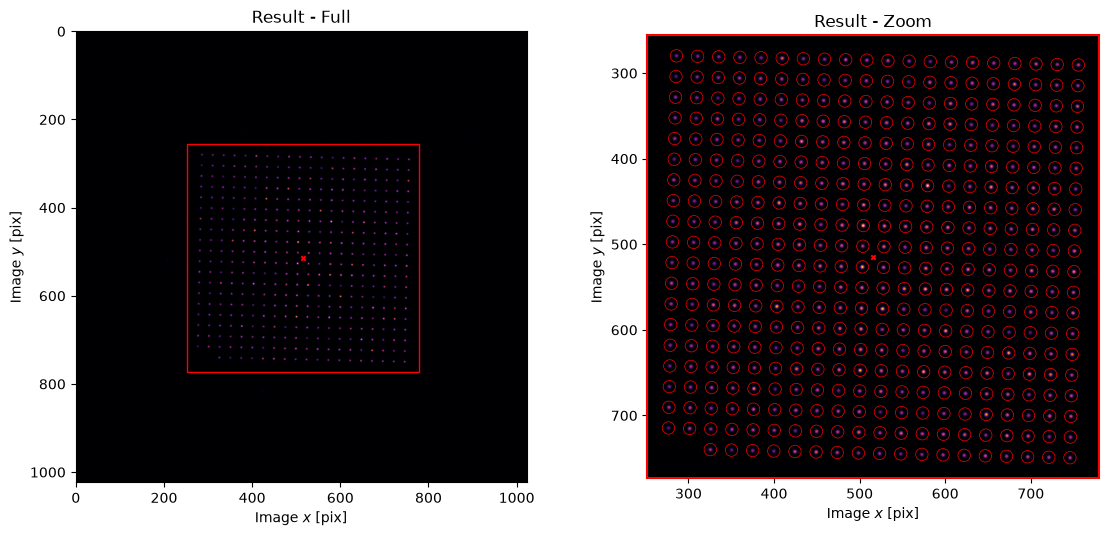

In [3]:
fs.fourier_calibrate(20, 20, autoexpose=True, plot=True);

#### The SLM Aperture

Zernike polynomials are defined on the unit disk like `lens()`es, so we need to identify where that disk lies on the SLM.
This is done with the `toolbox.Aperture` object attached to every SLM (`slm.aperture`), which:

- **Normalizes** any unit-disk function, setting how $Z_i$ (or a lens, axicon, etc.) is scaled and centered on the SLM.
- **Masks** the source amplitude and phase, so everything which consumes the source (holography, the wavefront correction inside `set_phase()`) sees only the illuminated region.

There are two ways to put an aperture on an SLM. First, we can set one directly with `slm.set_aperture()`:

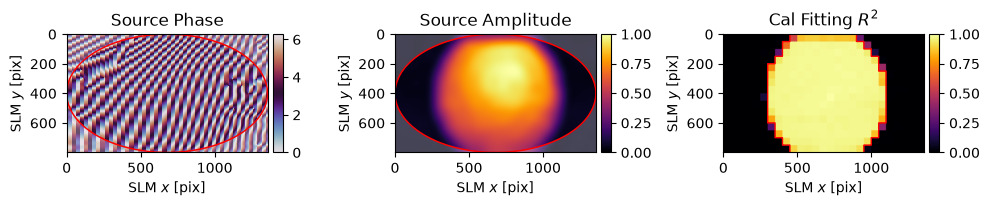

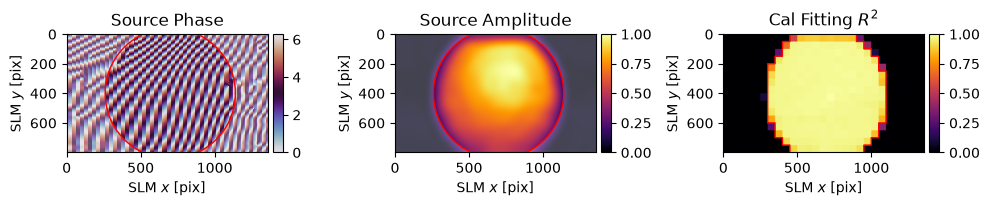

scale        : (0.00010269360269360268, 0.00010269360269360268)
center       : [475.81967213  11.06557377]
crops        : True
pupil radius : 440 pixels
source radius: 220 pixels


In [4]:
from slmsuite.holography.toolbox import Aperture

# Place a shorthand aperture...
aperture = Aperture(slm, "elliptical")
slm.set_aperture(aperture)
slm.plot_source();                      

# ...or specify one. `radius` is the 1/e *source* radius and the pupil is twice it,
# so 220 px places the pupil at the ~440 px which the fit below finds on its own.
slm.set_aperture(center=(700,400), radius=220, units="pix")
slm.plot_source();                      

# 1/r scale stored on the aperture  
print("scale        :", slm.aperture.scale)
# center in normalized units
print("center       :", slm.aperture.center)
# whether the aperture eliminates pixels
print("crops        :", slm.aperture.crops)
# radius of the actual aperture
print("pupil radius :", round(1 / slm.aperture.scale[0] / slm.pitch[0]), "pixels")
# 1/e source amplitude radius, here exactly half the pupil by construction
print("source radius:", round(slm.source_radius / slm.pitch[0]), "pixels")

Alternatively, use `slm.fit_aperture()` to measure one from the source amplitude roll-off. Note that whenever we apply an aperture, the SLM's grid shifts to the center of that aperture so that follow-on phase helpers are centered on the aperture. The Zernikes that we're about to apply will demonstrate this.

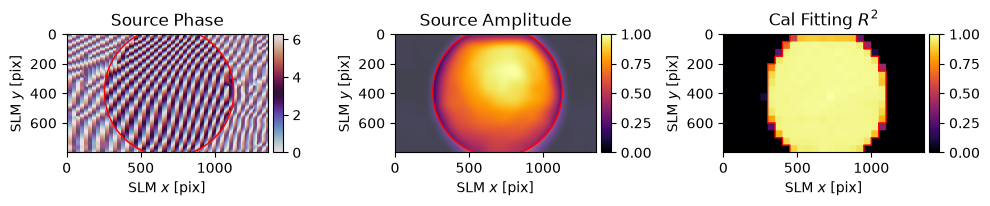

scale        : (0.00010339511445877272, 0.00010339511445877272)
center       : [ 300.14661277 -220.94515702]
crops        : True
pupil radius : 437 pixels
source radius: 377 pixels


In [5]:
# Fit the pupil to the rolloff of the measured source.
slm.fit_aperture() 
slm.plot_source();                      

print("scale        :", slm.aperture.scale)
print("center       :", slm.aperture.center)
print("crops        :", slm.aperture.crops)
print("pupil radius :", round(1 / slm.aperture.scale[0] / slm.pitch[0]), "pixels")
print("source radius:", round(slm.source_radius / slm.pitch[0]), "pixels")

In addition to the centering/scale adjustments, also note the different source radius now.
This is because `fit_aperture()` measures pupil and source radius separately 
(the pupil from power roll-off, the source from the amplitude moments)
whereas `set_aperture()` couples the two: it only describes a Gaussian
truncated at twice its $1/e$ amplitude radius, so source radius = half pupil
radius.

#### Zernike Indexing

There are many ways to index Zernike polynomials. `slmsuite` supports a number of conventions,
but uses the 1D ANSI `"ansi"` indexing $i$ as the default.
We can find the mapping $Z_i = Z_n^l$ between ANSI and the canonical definition 
`"radial"` consisting of the radial $n$ and azimuthal $l$ orders:

In [6]:
from slmsuite.holography.toolbox.phase import zernike_convert_index

ansi = np.arange(10)
radial = zernike_convert_index(ansi, from_index="ansi", to_index="radial")

# Print the results
print("i", "|", "n", "l")
print("--+-----")
for i, (n, l) in enumerate(radial):
    print(i, "|", n, l)

i | n l
--+-----
0 | 0 0
1 | 1 -1
2 | 1 1
3 | 2 -2
4 | 2 0
5 | 2 2
6 | 3 -3
7 | 3 -1
8 | 3 1
9 | 3 3


The nature of the radial $n$ and azimuthal $l$ orders make it often convenient to arrange the polynomials in a pyramid:

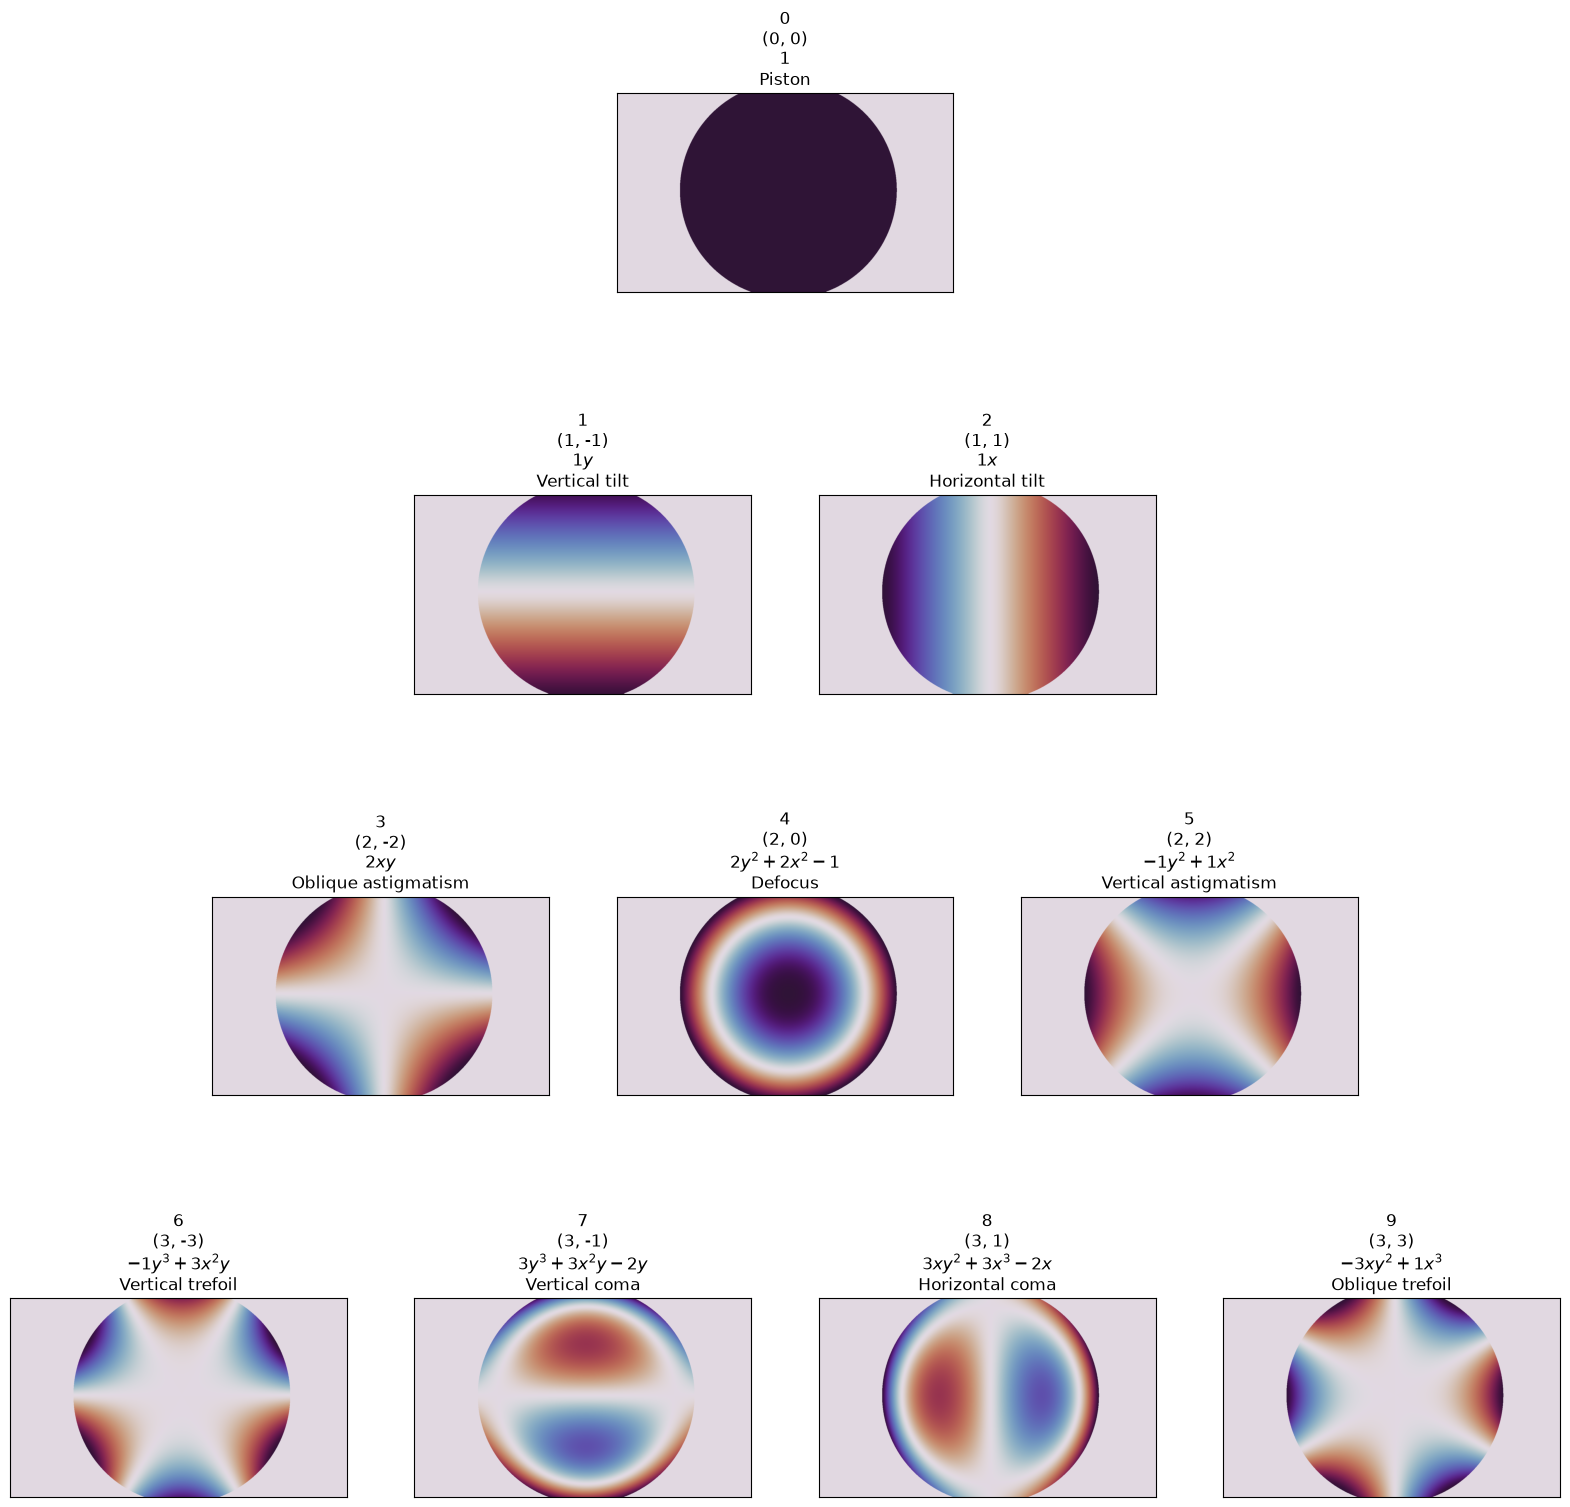

In [7]:
from slmsuite.holography.toolbox.phase import zernike_pyramid_plot

plt.figure(figsize=(20,20))
zernike_pyramid_plot(slm, order=3)

Notice how the polynomials are translated and scaled to sit on the measured source, rather
than on the display. This is `slm.aperture` at work: its scaling sizes the polynomials, and
its center is the origin of `slm.grid`, so the basis acts on the beam itself without, for
instance, laterally steering it while focusing.

`slmsuite` also supports derivatives (computed analytically via the power rule before
rendering, for speed):

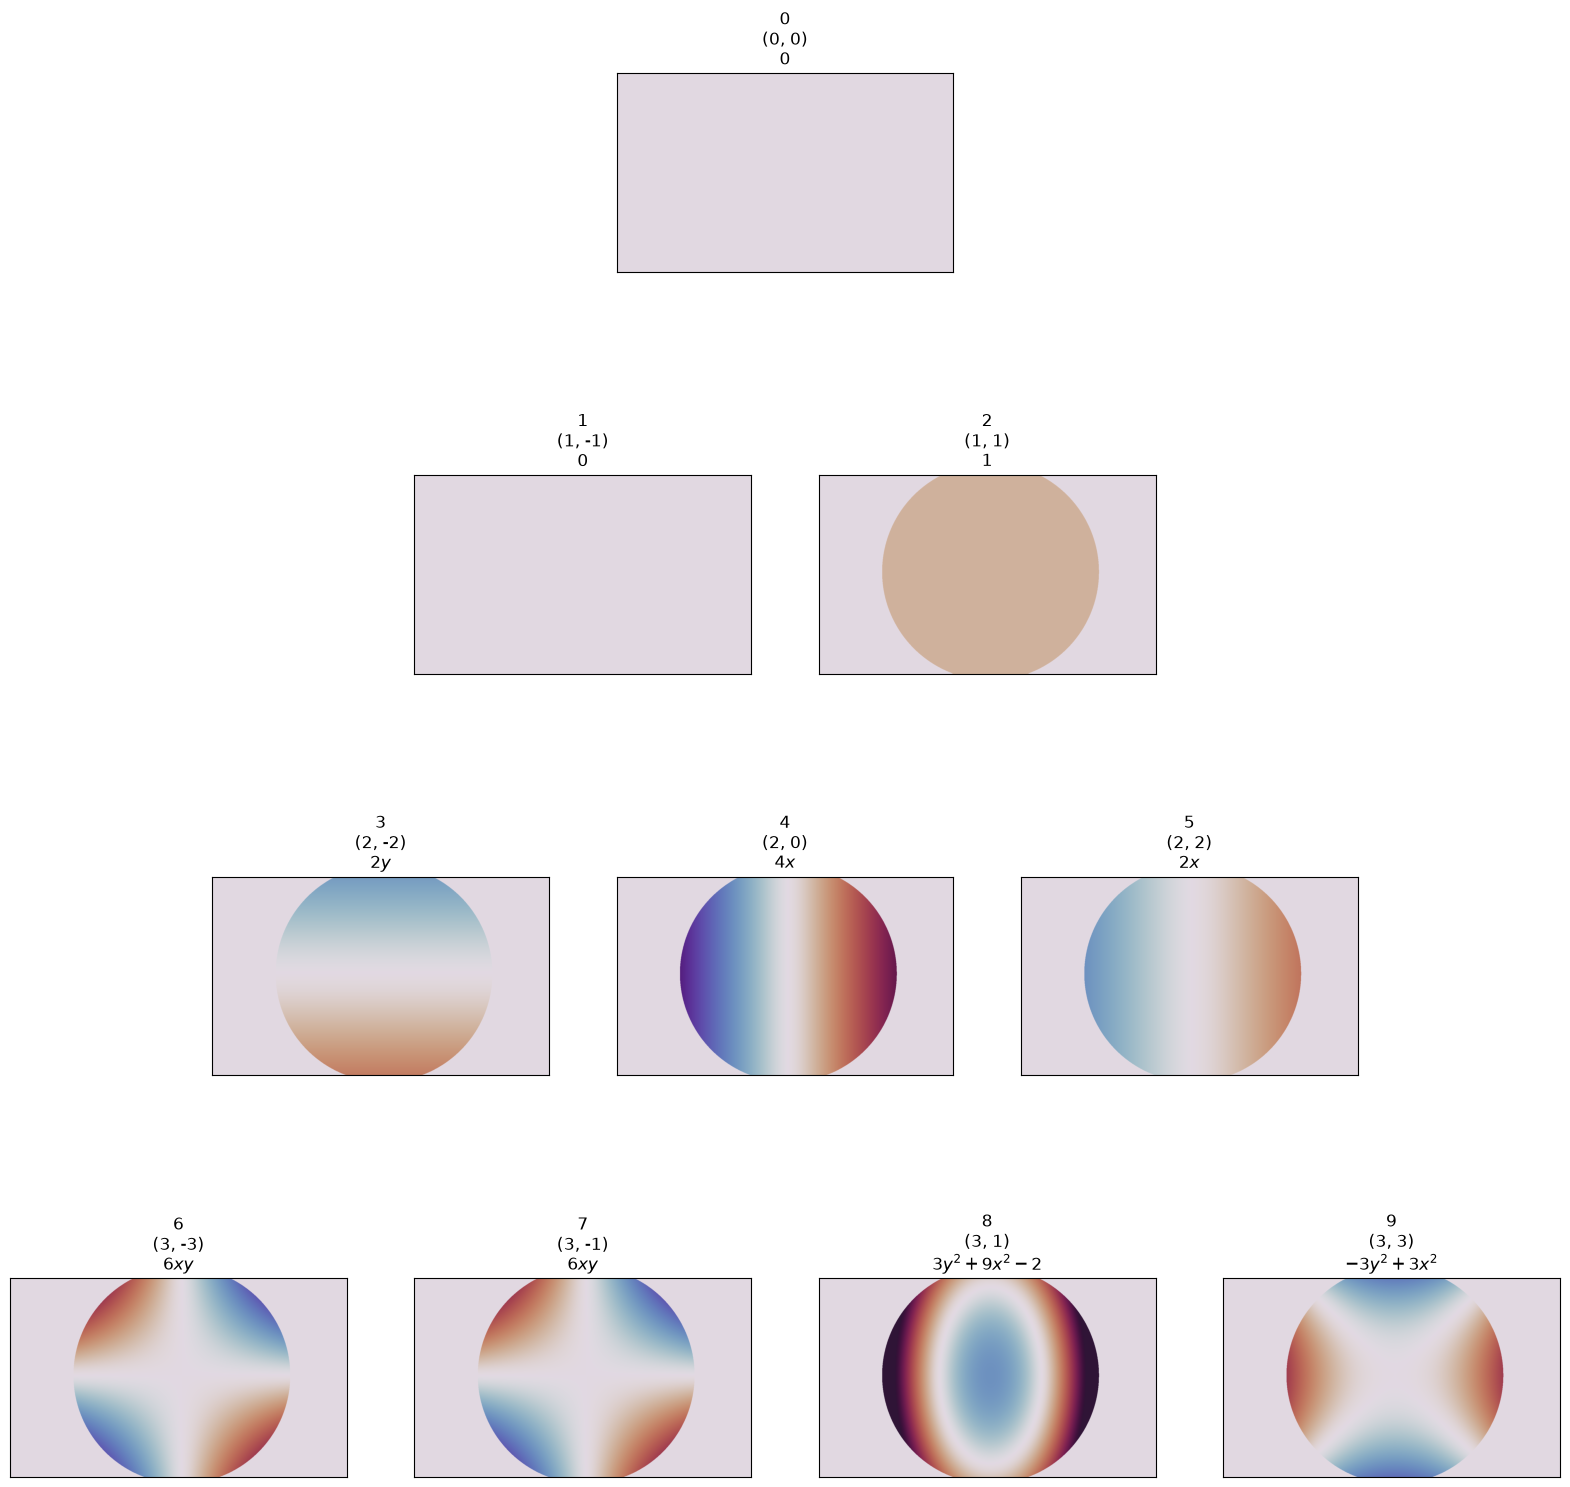

In [8]:
plt.figure(figsize=(20,20))
zernike_pyramid_plot(slm, order=3, derivative=(1, 0), scale=5)    # Adjust the scale because the derivative exceeds [-1, 1]

We can do this for very high order $n$:

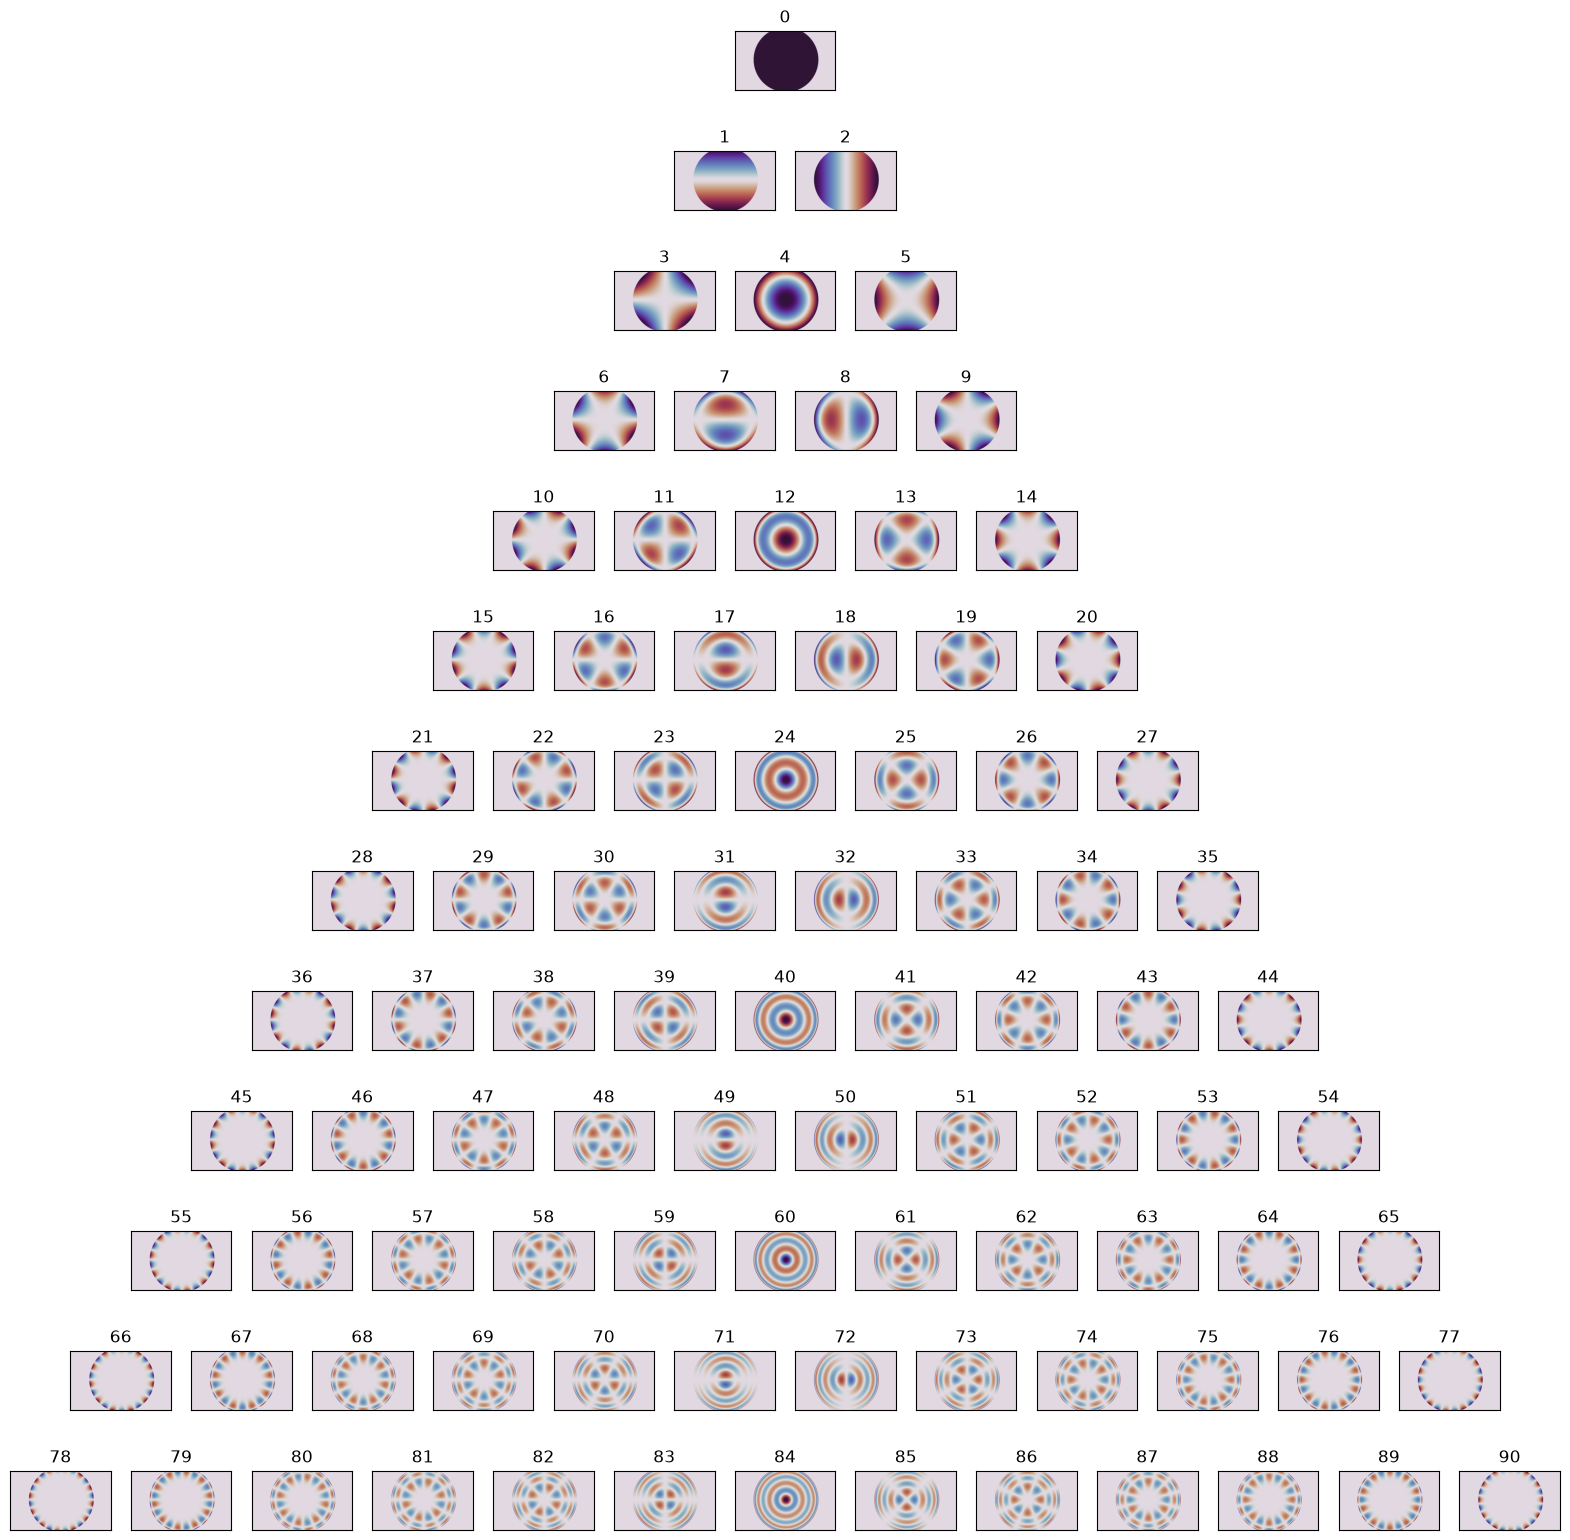

In [9]:
from slmsuite.holography.toolbox.phase import zernike_pyramid_plot

plt.figure(figsize=(20,20))
zernike_pyramid_plot(slm, order=12, titles=["ansi"])

To actually grab the phase of a single polynomial, we can use `zernike()`.
This is of the same style as other functions in `toolbox.phase`, where
the SLM is passed as `grid=` to give the function information about the
scaling of the polynomial, which it reads from `slm.aperture`.


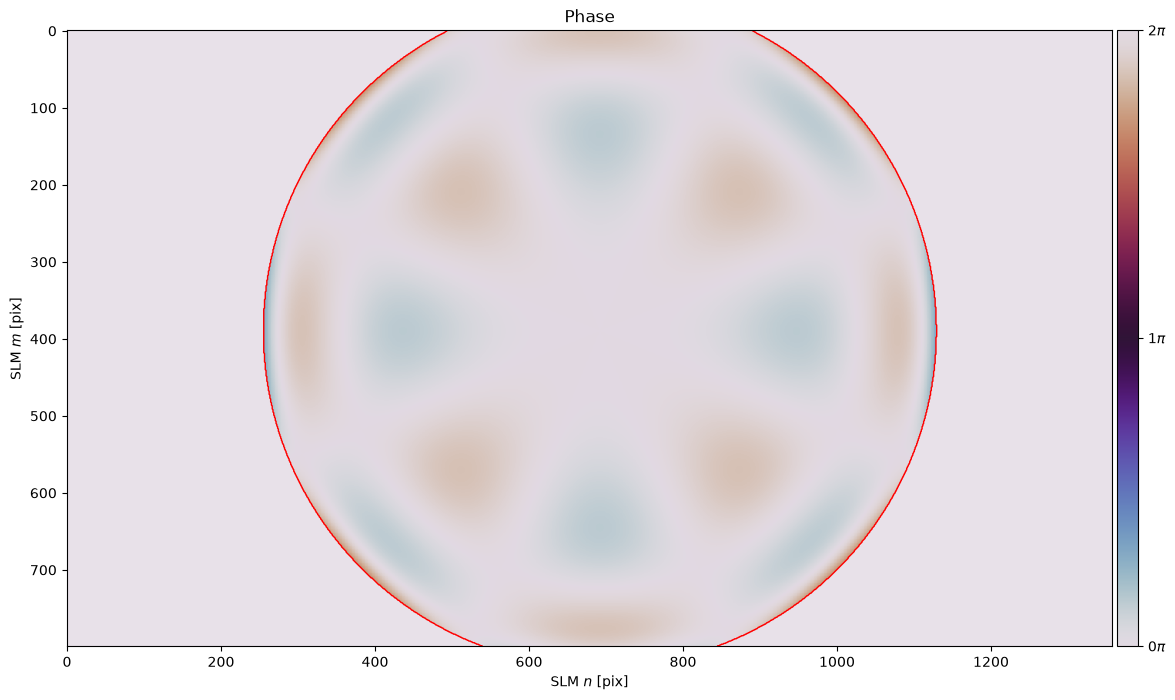

In [10]:
from slmsuite.holography.toolbox.phase import zernike

zernike_42 = zernike(slm, 42)

slm.plot(zernike_42);

The core function `zernike_sum()` supports generating stacks of sums of Zernike polynomials, with
the option for derivatives applied to each. The `weights=` term is here a `(4, 6)` matrix, 4 terms
for the requested ANSI indices, 6 terms for the 6 produced sums. These weights $w_i^{(j)}$ are
multiplied directly with $Z_i$ (normalized to $\pm 1$), to produce $\phi_j = \sum_i w_i^{(j)}Z_i$.

Two families of polynomial are exceptions to this $\pm 1$ normalization: the piston $Z_0$ is
identically 1, and the rotationally symmetric terms of order $n$ divisible by four ($Z_{12}$,
$Z_{40}$, ...) reach $+1$ but bottom out above $-1$ ($-1/2$ for $Z_{12}$).

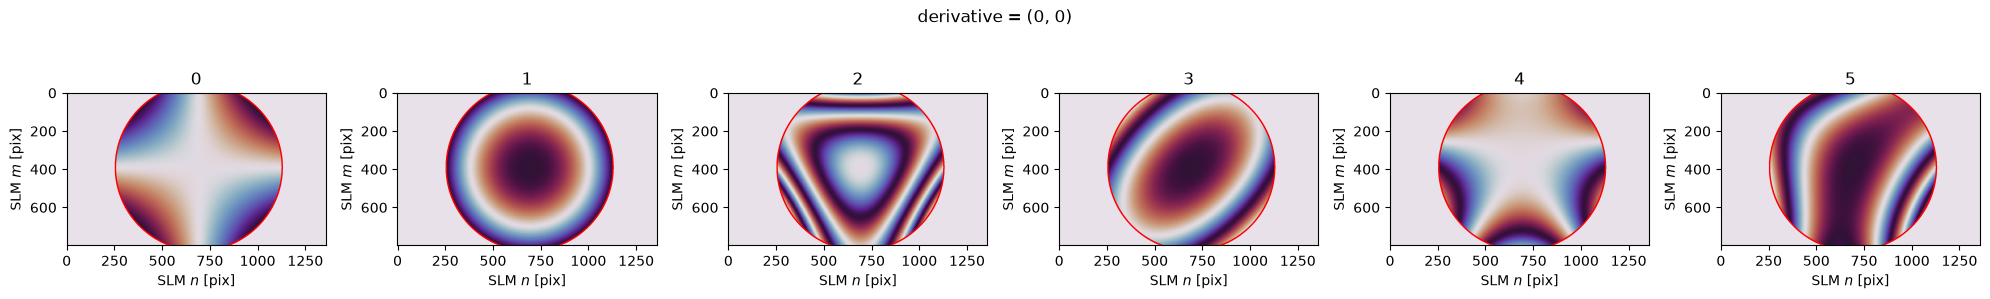

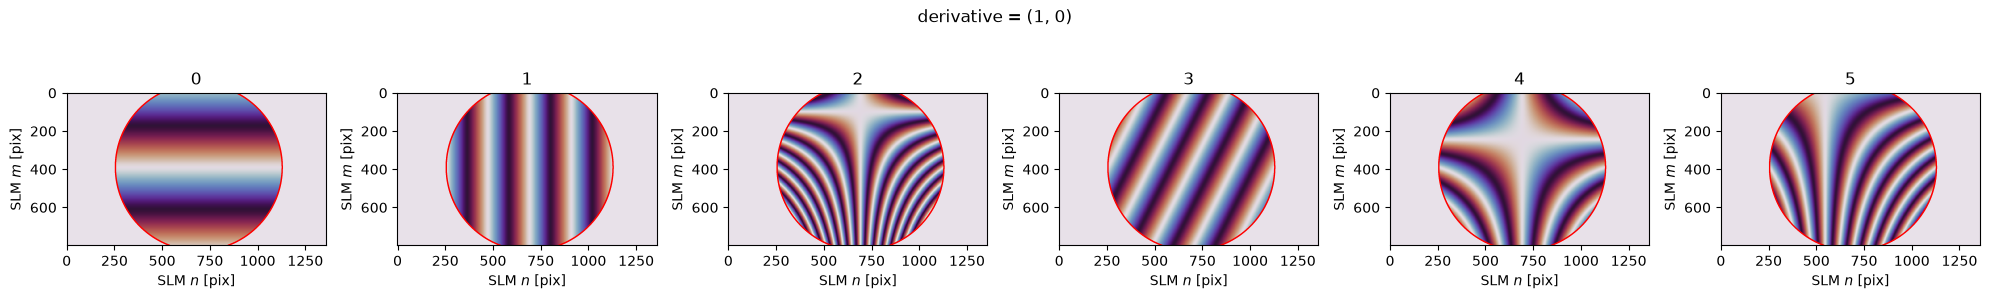

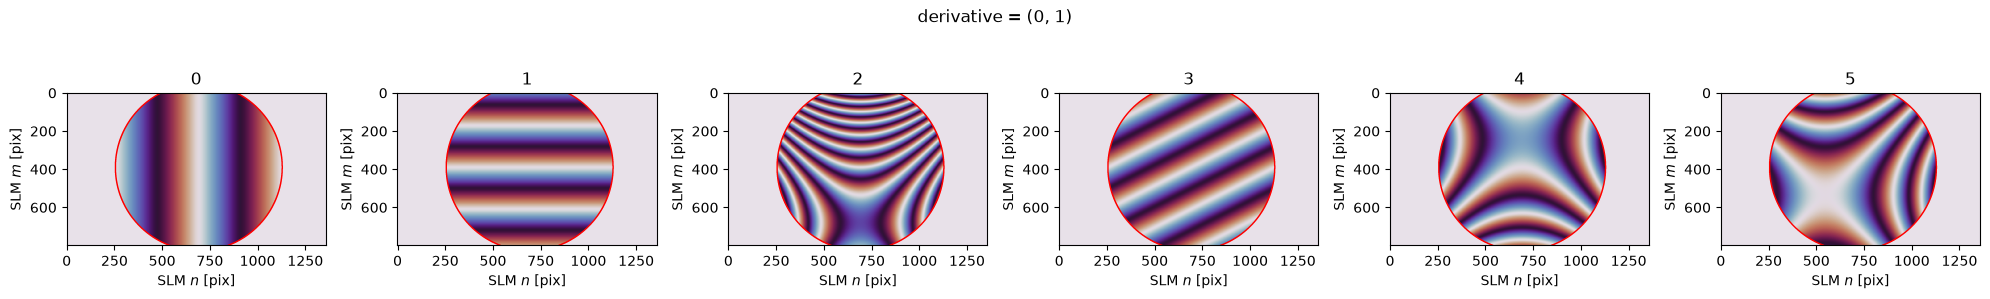

In [11]:
from slmsuite.holography.toolbox.phase import zernike_sum

for derivative in [(0,0), (1,0), (0,1)]:
    images = np.pi * zernike_sum(
        slm,
        indices=[3,4,5,6],
        weights=[
            [1,0,0,1,0,1],      # 3
            [0,1,2,1,0,1],      # 4
            [0,0,0,0,1,1],      # 5
            [0,0,2,0,1,1],      # 6
        ],
        derivative=derivative
    )

    fig, axs = plt.subplots(1, 6, figsize=(20,3))

    for i, image in enumerate(images):
        plt.sca(axs[i])
        slm.plot(image, title=str(i), cbar=False)

    plt.suptitle(f"derivative = {derivative}")
    plt.tight_layout()
    plt.show()

#### The Zernike Basis

Computing the polynomials is the expensive part of `zernike_sum()`; the weighted sum afterwards is
cheap. Any routine which reuses the same grid and the same indices, as iterative wavefront retrieval
does, should pay that cost once. A `ZernikeBasis` is that "once" --- it renders the images up front,
with the indices and aperture baked in, and then stands in for the grid:

- Give it to `zernike_sum()` along with weights to efficiently compute the phase mask.
- Give it to `image_zernike_fit()` to turn a measured phase back into weights (by default fit
  against the phase *gradient*, so a wrapped measurement needs no unwrapping).

In [12]:
import time
from slmsuite.holography.toolbox.phase import ZernikeBasis

indices = list(range(1, 66))            # Every polynomial through radial order 10.
basis = ZernikeBasis(slm, indices)

weights = np.random.default_rng(0).normal(0, 0.3, len(indices))

# The basis stands in for the grid, and gives the same answer.
print(len(basis), "polynomials rendered as", basis.basis.shape)
print("same as passing the grid:", np.allclose(
    zernike_sum(basis, None, weights), zernike_sum(slm, indices, weights)
))

def ms(call):
    start = time.perf_counter()
    float(call())                       # Read one value back to synchronize a GPU backend.
    return 1e3 * (time.perf_counter() - start)

# Computing dominates; reusing the result is nearly free.
print("\ncomputing the basis: {:6.1f} ms".format(ms(lambda: ZernikeBasis(slm, indices).basis[0, 0, 0])))
print("using it           : {:6.1f} ms".format(ms(lambda: zernike_sum(basis, None, weights)[0, 0])))

65 polynomials rendered as (65, 800, 1358)
same as passing the grid: True

computing the basis:   18.9 ms
using it           :    0.4 ms


In practice you rarely build one yourself. Every ordinary call which takes a grid --- `zernike()`,
`zernike_sum()`, `image_zernike_fit()` --- looks in a shared cache for a matching basis first and
renders one only on a miss. The first Zernike call against an SLM is slow and the rest are fast,
with no change to your code.

A cached basis is identified by the **grid**, the **indices**, the **aperture**, and `use_mask`.
Change any of those and another basis is rendered, while the previous one stays cached, so coming
back to it is fast again. `derivative=` and `use_mask=np.nan` take a different code path which skips
the cache, and so re-render on every call.

The cache holds the last 32 bases, and `clear_zernike_basis_cache()` empties it. That matters most
on a GPU, where each basis is `D` full-resolution images sitting in device memory.

In [13]:
from slmsuite.holography.toolbox.phase import clear_zernike_basis_cache
from slmsuite.holography.analysis import image_zernike_fit

# The very first Zernike call of a session also builds coefficient tables and compiles GPU
# kernels, so warm those up and then empty the basis cache.
for kwargs in ({}, {"derivative": (1, 0)}, {"aperture": "circular"}, {"use_mask": np.nan}):
    zernike_sum(slm, indices, weights, **kwargs)

measured = zernike_sum(slm, indices, weights)
image_zernike_fit(measured, slm, order=indices)

clear_zernike_basis_cache()

for label, note, call in (
    ("first call",          "renders a basis",
        lambda: zernike_sum(slm, indices, weights)),
    ("the same call again", "reuses it",
        lambda: zernike_sum(slm, indices, weights)),
    ("fewer indices",       "another basis",
        lambda: zernike_sum(slm, indices[:30], weights[:30])),
    ("another aperture",    "another basis",
        lambda: zernike_sum(slm, indices, weights, aperture="circular")),
    ("back to the first",   "still cached",
        lambda: zernike_sum(slm, indices, weights)),
    ("a derivative",        "not cached: recomputed",
        lambda: zernike_sum(slm, indices, weights, derivative=(1, 0))),
    ("the same derivative", "recomputed again",
        lambda: zernike_sum(slm, indices, weights, derivative=(1, 0))),
    ("use_mask=np.nan",     "not cached either",
        lambda: zernike_sum(slm, indices, weights, use_mask=np.nan)),
    ("fitting on the SLM",  "shares the cached basis",
        lambda: image_zernike_fit(measured, slm, order=indices)),
    ("fitting on slm.grid", "a bare grid loses slm.aperture: another basis",
        lambda: image_zernike_fit(measured, slm.grid, order=indices)),
):
    print("{:<20} {:6.1f} ms   {}".format(label, ms(lambda: call()[0, 0]), note))

first call             18.5 ms   renders a basis
the same call again     0.6 ms   reuses it
fewer indices           5.8 ms   another basis
another aperture       17.4 ms   another basis
back to the first       0.5 ms   still cached
a derivative            4.8 ms   not cached: recomputed
the same derivative     4.2 ms   recomputed again
use_mask=np.nan         4.1 ms   not cached either
fitting on the SLM      4.7 ms   shares the cached basis
fitting on slm.grid    33.0 ms   a bare grid loses slm.aperture: another basis


#### 3D "Compressed Spot" Holography

3D spots is a first simple application of the math which "bakes" aberration into a
hologram. Indeed, the $Z_4 = Z_2^0$ Zernike polynomial is exactly defocus, and it is
this parabolic term which we will use for translating (aberrating) in $z$.
Our previous examples effectively only used the $x = Z_2 = Z_1^1$ and $y = Z_1 = Z_1^{-1}$ terms.

Let's start by making a desired pointcloud in the camera's pixel `"ij"` coordinates.

In [14]:
from slmsuite.holography.toolbox import convert_vector

N = 100
x = np.arange(N) / 20

zeroth_order_ij = convert_vector((0,0), from_units="norm", to_units="ij", hardware=fs)

vectors_ij = np.vstack((
    50 * (x + 1) * np.cos(2 * np.pi * x) + zeroth_order_ij[0],
    50 * (x + 1) * np.sin(2 * np.pi * x) + zeroth_order_ij[1],
    200 * np.cos(1.5 * np.pi * x)                             
))

Unit conversions are a major focus of `slmsuite`. The core method `toolbox.convert_vector()`
described previously supports 3D points and converts between the various units.
For most units in SLM coordinates, "focal power" $1/f$ (wavelength-normalized like other `slmsuite` units) is used for $z$ since the corresponding lens phase is $\phi(r) \propto (1/f)r^2$ at radius $r$ from the optical axis. Read [the docs](https://slmsuite.readthedocs.io/en/latest/_autosummary/slmsuite.hardware.cameraslms.FourierSLM.html#slmsuite.hardware.cameraslms.FourierSLM.ijcam_to_kxyslm) for additional details on $z$ units.

With Fourier calibration and knowledge of the camera's pixel pitch in microns, 
`slmsuite` can convert between SLM-space and camera-space units, depth included:
the Fourier calibration supplies the affine transformation and the effective focal
length $f_\text{eff}$, while the pitch supplies the physical scale.
Coordinates related to camera-space are `"ij"`, `"ijraw"`, length units (e.g., `"cm"`), and magnification units.
If you don't have the `.pitch_um` attribute of the camera set, you will probably see
`nan` for all the $z$ coordinates except for the raw camera units `"ij"` and `"ijraw"`.

In [15]:
from slmsuite.holography.toolbox import print_blaze_conversions

print_blaze_conversions(
    vectors_ij[:, 0],       # Print the first vector.
    from_units="ij",
    hardware=fs,
    shape=(2048, 2048)
)

'rad' : [-8.92225057e-04 -2.07019994e-05  1.16120231e-08]
'mrad' : [-8.92225057e-01 -2.07019994e-02  1.16120231e-08]
'deg' : [-5.11207302e-02 -1.18613719e-03  1.16120231e-08]
'norm' : [-8.92225057e-04 -2.07019994e-05  1.16120231e-08]
'kxy' : [-8.92225057e-04 -2.07019994e-05  1.16120231e-08]
'knm' : [9.83560265e+02 1.02306169e+03 1.16120231e-08]
'freq' : [-1.97459644e-02 -4.58159002e-04  1.16120231e-08]
'lpmm' : [-1.82833004e+00 -4.24221298e-02  1.16120231e-08]
'zernike' : [-54.2193449   -1.25803331   1.70619133]
'ij' : [565.83566465 514.59409512 200.        ]
'ijraw' : [2713.83566465 1514.59409512  200.        ]
'm' : [0.00155039 0.00140999 0.000548  ]
'cm' : [0.15503897 0.14099878 0.0548    ]
'mm' : [1.55038972 1.40998782 0.548     ]
'um' : [1550.38972114 1409.98782063  548.        ]
'nm' : [1550389.72114374 1409987.820631    548000.        ]
'mag_m' : [0.00155039 0.00140999 0.000548  ]
'mag_cm' : [0.15503897 0.14099878 0.0548    ]
'mag_mm' : [1.55038972 1.40998782 0.548     ]
'mag_um

The `"zernike"` conversion is listed as the coefficients (in radians) of the $Z_2, Z_1,
Z_4$ terms, which correspond to $x,y,z$, the tilt and focus terms (see the pyramid).

We can now make the hologram with these 3D points.

In [16]:
from slmsuite.holography.algorithms import CompressedSpotHologram

hologram = CompressedSpotHologram(
    spot_vectors=vectors_ij,
    basis="ij",                 # For 3D spots, the basis defaults to Zernike terms [2,1,4] = [x,y,z].
    cameraslm=fs
)
hologram.optimize()

[INF] 21:28:04 CompressedSpotHologram Initialized CompressedSpotHologram.


100%|██████████| 20/20 [00:00<00:00, 318.73it/s]


While holography in previous tutorials was bound to the flat $k_{nm}$ grid of a 2D FFT,
this hologram uses ["compressed spot holography"](https://doi.org/10.3390/mps2010002)
which maps power from the nearfield to the farfield at a "compressed set" of points
defined here by `vectors_ij`. `CompressedSpotHologram` generalizes this to [arbitrary sets
of Zernike polynomials](https://doi.org/10.48550/arXiv.2505.08777).

Let's take a look at what we made in 3D (a restricted set of Zernike polynomials):

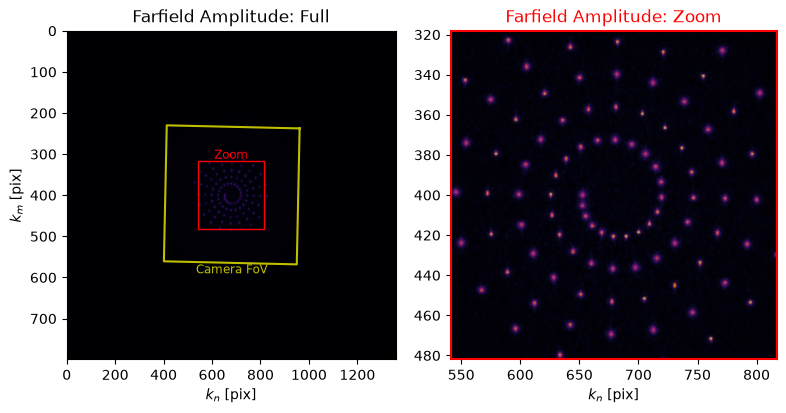

In [17]:
hologram.plot_farfield(limit_padding=-0.4);

Under the hood, `slmsuite` uses `convert_vector()` to translate the `"ij"` coordinates into
`"zernike"` space, then builds a basis of "compressed kernels" which map to each spot in this
three-dimensional aberration space. Each kernel is a `zernike_sum()` over the hologram's
`zernike_basis` --- here the default `[2,1,4]` --- with that spot's aberration vector as the
`weights=`, so this is the cache of the previous section at work: the three polynomials are
rendered once and each kernel is then a single matrix product. The stack of kernels is itself
held on the hologram and rebuilt only when `spot_zernike` changes, which is what makes the
dynamic examples below cheap.

We can look at this basis of Zernike polynomial kernels (only plotting the first ten for speed)
by feeding the vector in aberration space as `weights=` of `zernike_sum()`. Note that the
hologram builds its kernels on a pre-scaled grid with `use_mask=False` so that the edge of the
aperture cannot cause artifacts, whereas we plot the masked version below.

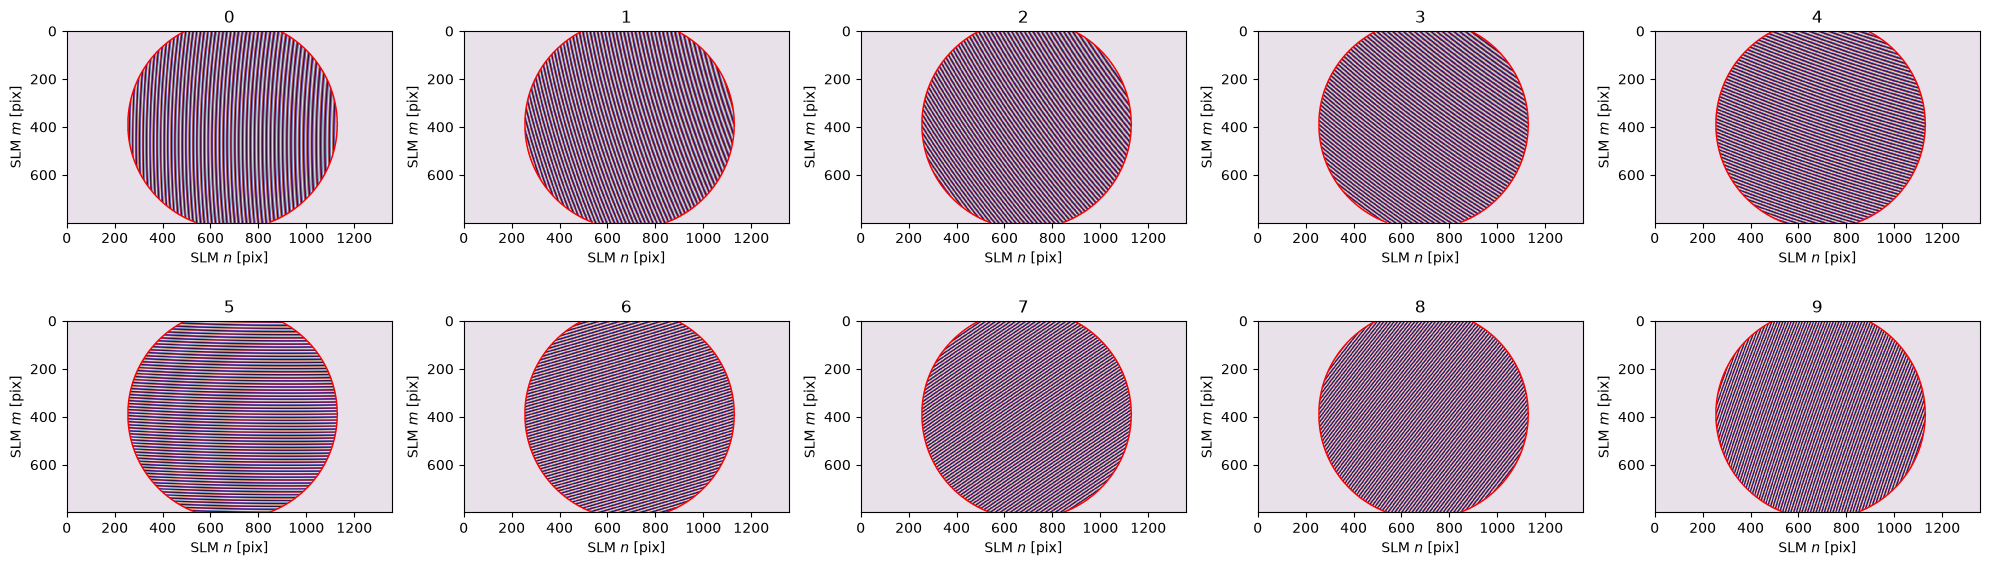

In [18]:
# Get the coordinates in "Zernike space" using the [2,1,4] = [x,y,z] terms.
vectors_zernike = convert_vector(
    vectors_ij,
    from_units="ij",
    to_units="zernike",
    hardware=fs
)

# Plot only the first 10.
images = np.pi * zernike_sum(
    slm,
    indices=None,       # For 3D spots, the basis defaults to Zernike terms [2,1,4].
    weights=vectors_zernike[:, :10]
)

fig, axs = plt.subplots(2, 5, figsize=(20,6))
axs = axs.ravel()

for i, image in enumerate(images):
    plt.sca(axs[i])
    slm.plot(image, title=str(i), cbar=False)

plt.tight_layout()
plt.show()

#### Zernike Spot Holography

However, this technique is extensible to far more than the three $Z_2, Z_1, Z_4$ terms.
Let's make a realized Zernike pyramid in a single hologram.

First, let's find the `"zernike"` coordinates of the pyramid corresponding to desired
`"ij"` positions for arrangement according to the radial and azimuthal orders $n$ and $l$.

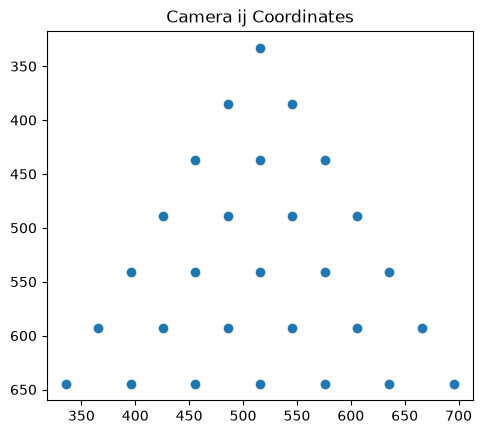

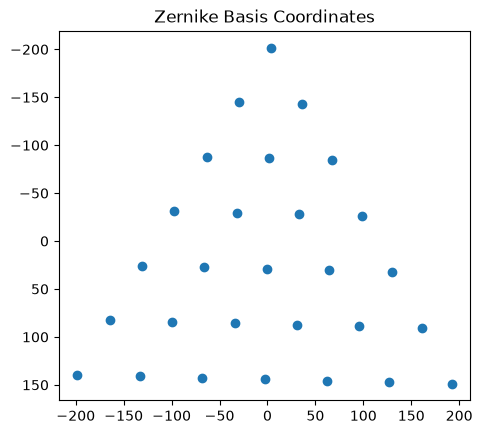

In [19]:
from slmsuite.holography.toolbox import format_vectors

# Generate a Zernike for each ij point
center = fs.zeroth_order_ij
scale = 30

N = 28
i = np.arange(N)
nl = zernike_convert_index(i, from_index="ansi", to_index="radial")
ij = scale * np.vstack((nl[:, 1], (nl[:, 0] - 3.5) * np.sqrt(3))) + center
sz = convert_vector(ij, from_units="ij", to_units="zernike", hardware=fs)

# Plot the results 
plt.title("Camera ij Coordinates")
plt.scatter(ij[0], ij[1])
plt.gca().set_aspect("equal")
plt.gca().invert_yaxis()
plt.show()

plt.title("Zernike Basis Coordinates")
plt.scatter(sz[0], sz[1])
plt.gca().set_aspect("equal")
plt.gca().invert_yaxis()
plt.show()

base = np.zeros((N,N))
base[2, :] = sz[0]      # Tilt x term
base[1, :] = sz[1]      # Tilt y term

We impart the Zernike term for each spot by adding a perturbation in Zernike-space,
which we have requested to be $N$-dimensional; one order for each spot.
The second and third rows correspond to the steering to position the spot at the correct
$n,l$ coordinate in the pyramid in 2D space, according to the $y = Z_1$ and $x = Z_2$
terms. Imparting the perturbation for $Z_i$ on the correct spot at the correct $n,l$
coordinate is as simple as adding an identity matrix. The first row is the piston $Z_0$, a
constant phase which cannot shape a spot, so the tip of the pyramid stays unperturbed and
`CompressedSpotHologram` warns that the term is unnecessary. Then, the $i$-th spot is given
the perturbation for $Z_i$:

In [20]:
perturbation = np.diag(np.ones(N))
print((base + 10*perturbation)[:10, :10].astype(int))

[[  10    0    0    0    0    0    0    0    0    0]
 [-201 -133 -144  -84  -86  -87  -26  -28  -29  -31]
 [   4   35  -19   66    1  -63   98   33  -31  -96]
 [   0    0    0   10    0    0    0    0    0    0]
 [   0    0    0    0   10    0    0    0    0    0]
 [   0    0    0    0    0   10    0    0    0    0]
 [   0    0    0    0    0    0   10    0    0    0]
 [   0    0    0    0    0    0    0   10    0    0]
 [   0    0    0    0    0    0    0    0   10    0]
 [   0    0    0    0    0    0    0    0    0   10]]


Then, we send these desired coordinates to optimization:

In [21]:
hologram = CompressedSpotHologram(
    spot_vectors=base + 5*perturbation,
    basis=i,
    cameraslm=fs
)

hologram.optimize()

[WRN] 21:28:06 holography.algorithms._spots Found ANSI index '0' (Zernike piston) in the zernike_basis; this is not necessary as spot phase is controlled externally.
[INF] 21:28:06 CompressedSpotHologram #2 Initialized CompressedSpotHologram.


100%|██████████| 20/20 [00:00<00:00, 2002.63it/s]


Let's see what we got:

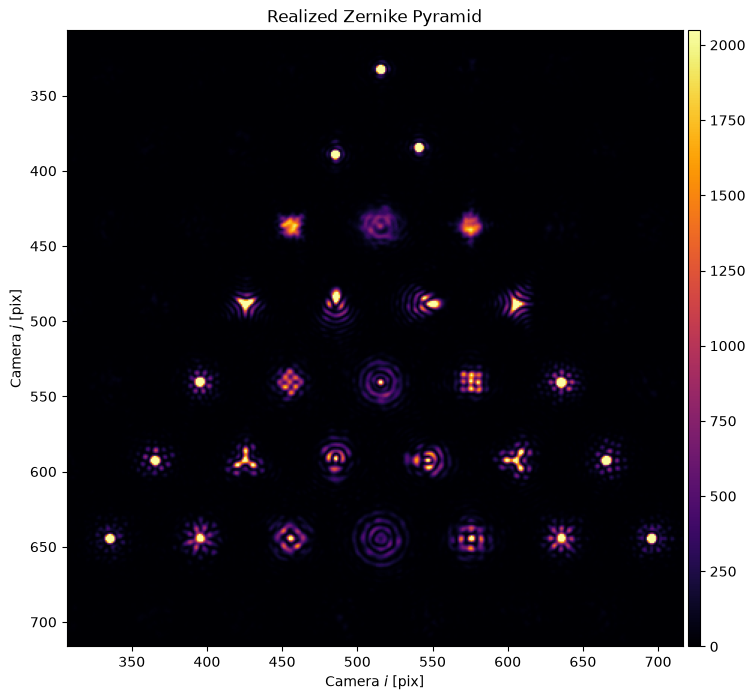

In [22]:
slm.set_phase(hologram.get_phase())
cam.plot(title="Realized Zernike Pyramid", clim=[0, cam.bitresolution // 2], limits=0.4);

This result looks even cleaner with virtual holography, but our real source distribution
isn't a perfect Gaussian on our physical SLM.

To show how programmable this technique of targeting points in Zernike-space
is, we make a fun .gif, modulating the level of perturbation. This time, we'll also use a custom CUDA kernel (`cuda=True`) to accelerate the process.

In [23]:
import tqdm

# Make the hologram
hologram = CompressedSpotHologram(
    spot_vectors=base,
    basis=i,
    cameraslm=fs,
    cuda=True
)
hologram.optimize("WGS-Leonardo", maxiter=50, verbose=False)

# Build the term oscillation movie.
imgs = []
X = 5 * np.sin(np.linspace(0, 2*np.pi, 25, endpoint=False))

# Get the image bounds
i0, i2 = np.amin(ij, axis=1).astype(int) - scale
i1, i3 = np.amax(ij, axis=1).astype(int) + scale

for x in tqdm.tqdm(X):
    # Optimize to the new position.
    hologram.spot_zernike = base + x*perturbation
    hologram.optimize("WGS-Leonardo", maxiter=20, verbose=False)

    # Project the pattern.
    slm.set_phase(hologram.get_phase())
    cam.flush()
    imgs.append(cam.get_image()[i2:i3,i0:i1])

[WRN] 21:28:06 holography.algorithms._spots Found ANSI index '0' (Zernike piston) in the zernike_basis; this is not necessary as spot phase is controlled externally.
[INF] 21:28:06 CompressedSpotHologram #3 Initialized CompressedSpotHologram.


100%|██████████| 25/25 [00:04<00:00,  5.06it/s]


(We use a helper function to render stored raw data with colormaps, saving the stack of images as a .gif):

In [24]:
from slmsuite.holography.analysis.files import save_image

save_image("ex-zernike-spots.gif", imgs, cmap="Blues", border=127, normalize=False, loop=0)
save_image("ex-zernike-spots-dark.gif", imgs, cmap="inferno", border=127, normalize=False, loop=0)

<!-- ![light](ex-zernike-spots.gif)  -->
![dark](ex-zernike-spots-dark.gif)

#### Interpolated Zernike Holography

Now that we have an understanding of the technique through analytic examples, let's start
to work towards applications.

For example, in full-field aberration correction we want to correct the
aberration -- described as a Zernike vector -- at every point in a field of
view.
Because aberration is generally smooth, we'll interpolate aberration between a finite number
of control points.
Let's start to take a look at this machinery with a toy example of interpolating between the
terms $Z_{\{16,17,18,19\}}$ located at the four corners of the field of view.

In [25]:
from slmsuite.holography.toolbox import convert_vector

height, width = cam.shape

# Define the corner points with some buffer
buffer = .1
cal_points_ij = np.array([
    np.array([buffer, 1-buffer, 1-buffer, buffer]) * width,
    np.array([buffer, buffer, 1-buffer, 1-buffer]) * height])
cal_points_zernike = convert_vector(cal_points_ij,
                                    from_units="ij",
                                    to_units="zernike",
                                    hardware=fs)

# Define the aberration vectors
zernike_indices = np.array([2, 1, 16, 17, 18, 19])
aberration = 20*np.array([
    [ 1., -1., -1., 1.],
    [ 1., -1.,  1.,-1.],
    [-1.,  1., -1., 1.], 
    [-1., -1.,  1., 1.]])
zernike_vectors = np.vstack((cal_points_zernike, aberration))

# Setup an analytic Fourier calibration: custom aberration vecs at four corners
fs.calibrations["wavefront_zernike"] = {
    "zernike_indices": zernike_indices,
    "calibration_points_ij": cal_points_ij,
    "corrected_spots": zernike_vectors
}

We'll cover the `wavefront_zernike` calibration in more detail in the [multipoint calibration tutorial](https://slmsuite.readthedocs.io/en/latest/_examples/multipoint_calibration.html).
For now, just realize that we're defining the wavefront calibration based on the provided Zernike vectors at the four corner points.

We can use a helper function `wavefront_calibrate_zernike_get` to interpolate/infer the Zernike aberration vector at any other point. For example, here we'll interpolate it at 24 points around a circle:

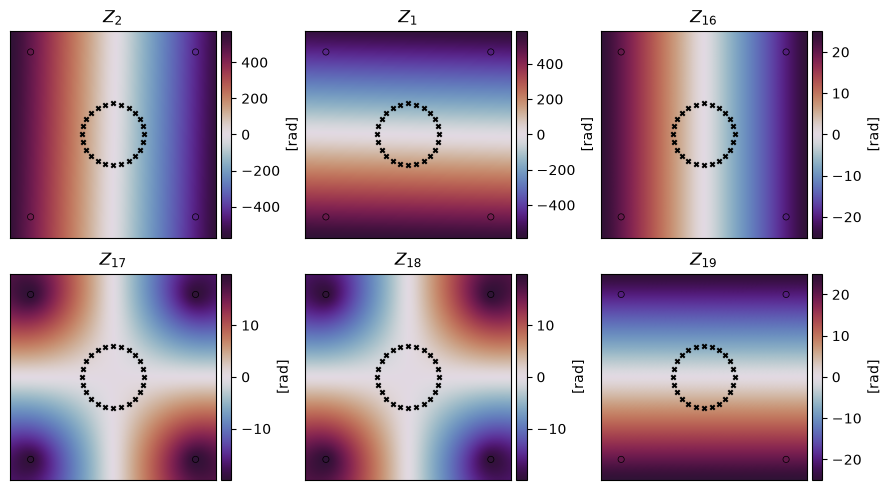

In [26]:
# Helper function to interpolate aberration at N circular points (rotated by theta) 
def get_vectors(theta=0, N=24, plot=False):

    # Get the angle of the points 
    theta_ = np.linspace(0, 2*np.pi, N, endpoint=False) + theta
    
    # Get the camera pixel locations
    path_ij = (
        np.mean(cal_points_ij, axis=1, keepdims=True)
        + .15 * np.array([[width], [height]]) * np.vstack((np.cos(theta_), np.sin(theta_)))
    )

    # Calculate the Zernike vecs at the points
    return fs.wavefront_calibrate_zernike_get(path_ij, from_units="ij", plot=plot)

get_vectors(plot=True);

The above plots show spatial dependence of each aberration term ($x$, $y$, and the higher order aberrations).
Producing a hologram which projects power into these vectors is the same as before:

In [27]:
hologram = CompressedSpotHologram(
    spot_vectors=get_vectors(),
    basis=zernike_indices,
    cameraslm=fs,
    cuda=True
)

hologram.optimize()

[INF] 21:28:12 CompressedSpotHologram #4 Initialized CompressedSpotHologram.


100%|██████████| 20/20 [00:00<00:00, 2497.80it/s]


When plotted, we observe a smooth interpolation between the aberration at the four corners.

[INF] 21:28:12 FLIR Cam Autoexpose: 1.81e-02 s - 2101/4095


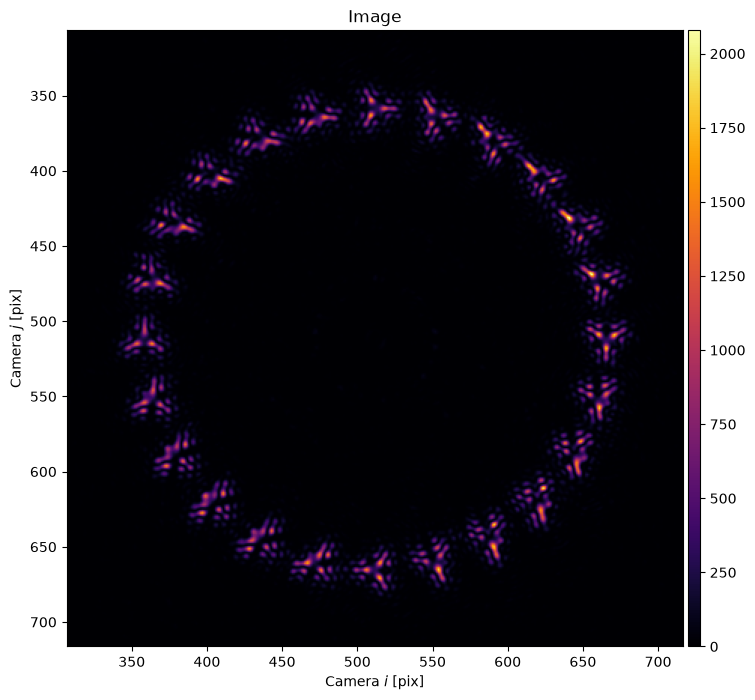

In [28]:
slm.set_phase(hologram.get_phase())
cam.autoexpose()
cam.plot(limits=.4);

The interpolator is cached until the calibration changes, so we can quickly recover the
aberration for a dynamic set of points, such as for the animated version of our example below:

In [29]:
import tqdm

N = 24

# Make the hologram
hologram = CompressedSpotHologram(
    spot_vectors=get_vectors(N=N),
    basis=zernike_indices,
    cameraslm=fs,
    cuda=True
)
hologram.optimize("WGS-Leonardo", maxiter=50, verbose=False)

# Build the term oscillation movie.
imgs = []
X = np.linspace(0, 1, 25, endpoint=False) * (2 * np.pi) / N

for x in tqdm.tqdm(X):
    # Optimize to the new position.
    hologram.spot_zernike = get_vectors(x, N=N)
    hologram.optimize("WGS-Leonardo", maxiter=20, verbose=False)

    # Project the pattern.
    slm.set_phase(hologram.get_phase())
    cam.flush()
    imgs.append(cam.get_image()[height//4:3*height//4, width//4:3*width//4])

[INF] 21:28:13 CompressedSpotHologram #5 Initialized CompressedSpotHologram.


100%|██████████| 25/25 [00:04<00:00,  5.61it/s]


Let's again save the data:

In [30]:
from slmsuite.holography.analysis.files import save_image

save_image("ex-zernike-interpolation.gif", imgs, cmap="Blues", border=127, normalize=True, loop=0)
save_image("ex-zernike-interpolation-dark.gif", imgs, cmap="inferno", border=127, normalize=True, loop=0)

<!-- ![light](ex-zernike-interpolation.gif)  -->
![dark](ex-zernike-interpolation-dark.gif)

We will combine Zernike interpolation with actual wavefront calibration in the next example
to realize steerable aberration-corrected spots across a field of view.

In [31]:
cam.close()
slm.close()